# KNN

## Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import os

#KNN
from sklearn.neighbors import KNeighborsRegressor

#Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Load Created Functions
from functions import *

# Set random seed for reproducibility
np.random.seed(40111) 

## Import Datasets

In [2]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_feature_selected/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_final.csv", index_col=0)
X_val   = pd.read_csv(f"{data_path}X_val_final.csv", index_col=0)
test    = pd.read_csv(f"{data_path}test_final.csv", index_col=0)

# Load target variables and squeeze to convert DataFrame to Series since they have only one column
y_train = pd.read_csv(f"{data_path}y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv(f"{data_path}y_val.csv", index_col=0).squeeze()

Create a function to choose the best k

Best number of neighbors: 5
MAE in train with 5 neighbors: 1184.426625
MAE in validation with 5 neighbors: 1496.831339


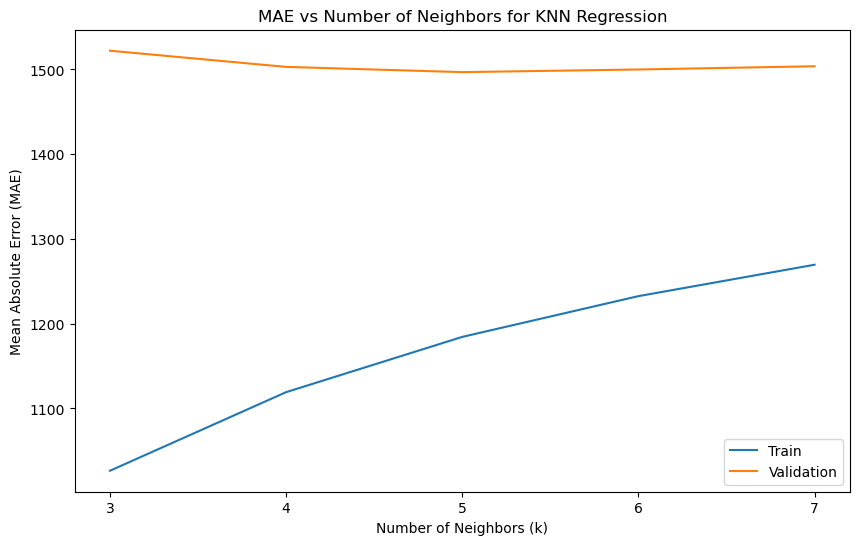

In [8]:
def choose_best_k(X_train, y_train, X_val, y_val):
    """Selects the best number of neighbors (k) for KNN regression based on lowest MAE on validation set."""
    K_list=np.arange(3,8)
    best_MAE=2000
    best_k=0           
    mae_list_train =[]
    mae_list_val =[]
    for n in K_list:
        model = KNeighborsRegressor(weights='uniform', 
                                    p=1,
                                    n_neighbors = n,
                                    n_jobs=-1
                                    ).fit(X_train, y_train)
        
        pred_train_knn = model.predict(X_train)
        pred_val_knn = model.predict(X_val)
        
        mae_train = mean_absolute_error(y_train, pred_train_knn)
        mae_val = mean_absolute_error(y_val, pred_val_knn)
        mae_list_train.append(mae_train)
        mae_list_val.append(mae_val)
        
        if(mae_val<best_MAE):
            best_MAE = mae_val
            best_k = n
    print("Best number of neighbors: %d" %best_k)
    print("MAE in train with %d neighbors: %f" % (best_k, mae_list_train[best_k - K_list[0]]))
    print("MAE in validation with %d neighbors: %f" % (best_k, best_MAE))

    # Plot MAE vs K
    plt.figure(figsize=(10,6))
    plt.plot(K_list, mae_list_train, label='Train')
    plt.plot(K_list, mae_list_val, label = 'Validation')
    plt.xticks(K_list)
    plt.legend()
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title('MAE vs Number of Neighbors for KNN Regression')


choose_best_k(X_train, y_train, X_val, y_val)

Fit and make predictions

In [9]:
model_KNN_Reg = KNeighborsRegressor(
    n_neighbors=5,
    weights='uniform',  # weights points by the inverse of their distance
    p=1,                # use Manhattan distance
    n_jobs=-1
)

model_KNN_Reg.fit(X_train, y_train)

# Make predictions for training and validation sets
predictions_train = model_KNN_Reg.predict(X_train)
predictions_val = model_KNN_Reg.predict(X_val)

Check the scores for both training and validation sets

In [10]:
evaluate_model(model_KNN_Reg, X_train, y_train)

{'R2': 0.9517654167706258,
 'Adjusted R2': 0.9517137754491423,
 'MAE': 1184.4266247655403,
 'MSE': 4544431.783481523,
 'RMSE': np.float64(2131.767291118222),
 'MedAE': 702.2000000000007,
 'MAPE (%)': 0.07334617736609866}

In [11]:
evaluate_model(model_KNN_Reg, X_val, y_val)

{'R2': 0.9291823546063372,
 'Adjusted R2': 0.9288780947774927,
 'MAE': 1496.8313392563343,
 'MSE': 6881360.721813754,
 'RMSE': np.float64(2623.2347820608347),
 'MedAE': 873.6000000000004,
 'MAPE (%)': 0.09157258306764743}